Here is the excerpt from the paper that tells us the values of alpha and beta:


We present our ZTF Hubble diagram for the 2629 non-peculiar SNe~Ia that pass our quality cuts in Figure~6. These SNe~Ia have been standardized using the methodology detailed in Ginolin et~al.~(2024), given the SALT2 stretch and color parameters and host local environmental properties (for example, Sullivan et~al.~2010; Rigault et~al.~2020). Following that paper, we adopt the nuisance parameter values $\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


The standardized distance modulus for each Type~Ia supernova is computed using the Tripp (1998) relation:

The observed distance modulus in the SALT2 framework is given by: 

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c
$



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize


In [2]:
# Read the following file:

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop.csv")


# Define the following global parameters:

alpha = 0.161
beta  = 3.05

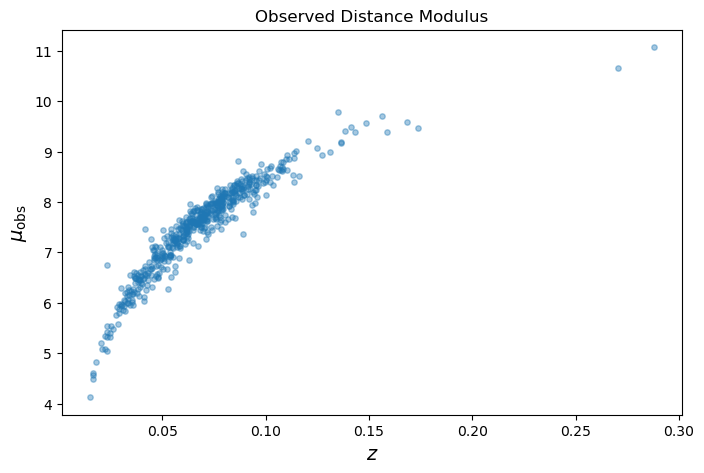

In [3]:
df["mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"]

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4)  # Note desi redshift is used b/c its more percise.
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu_{\mathrm{obs}}$", fontsize=14)
plt.title("Observed Distance Modulus")
plt.show()

# Now We Add Flat Lambda CDM Cosmology For Comparison #

And its plain to see how we need to marginalize for H_o and M_b in order to be able to find the constant that will move our raw data up to the flat lambda CDM cosmology curve that is being defined here. 

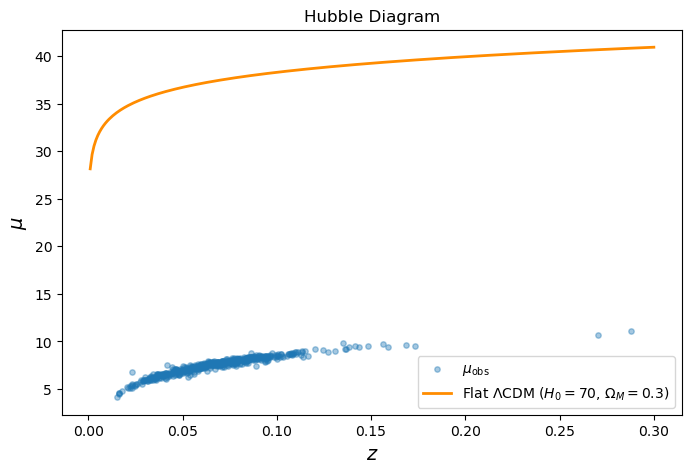

In [4]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z_grid = np.linspace(0.001, 0.3, 300)
mu_th = cosmo.distmod(z_grid).value

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_th, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram")
plt.legend()
plt.show()

# Distribution of Uncorrected Residuals is Gaussian #

This will become important later

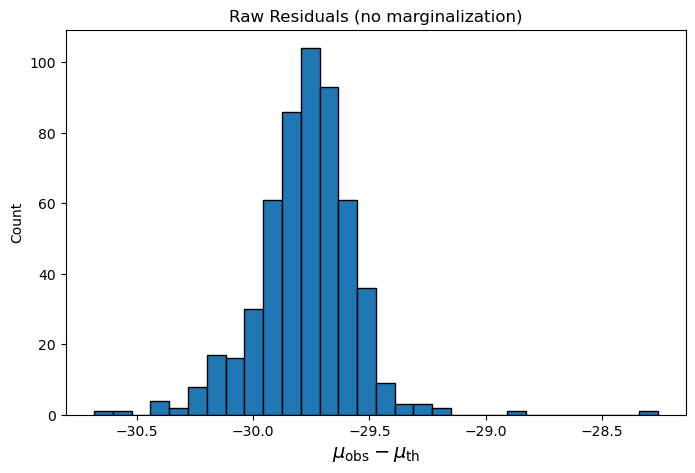

In [5]:
mu_th = cosmo.distmod(df["DESI_METADATA_Z"]).value
raw_residuals = df["mu_obs"] - mu_th

plt.figure(figsize=(8, 5))
plt.hist(raw_residuals, bins=30, edgecolor="black")
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$", fontsize=14)
plt.ylabel("Count")
plt.title("Raw Residuals (no marginalization)")
plt.show()

# Now lets do the error Propagation from the SALT 2 Model Error #

General Form of the Error Propagation Formula for $y = f(x_1, x_2, \ldots, x_n)$

$
\sigma_y^2 =
\sum_{i=1}^{n}
\left(
\frac{\partial f}{\partial x_i}
\right)^2
\sigma_{x_i}^2
+
\sum_{i \ne j}
2\,
\frac{\partial f}{\partial x_i}
\frac{\partial f}{\partial x_j}
\mathrm{Cov}(x_i, x_j).
$

Using the standard error propagation formula:

$$
\sigma_{\mu,\text{obs}} = \sqrt{
\left(\frac{\partial \mu}{\partial x_0}\right)^2 \sigma_{x_0}^2
+\left(\frac{\partial \mu}{\partial x_1}\right)^2 \sigma_{x_1}^2
+\left(\frac{\partial \mu}{\partial c}\right)^2 \sigma_c^2
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial x_1}\right)\mathrm{Cov}(x_0,x_1)
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_0,c)
+ 2\left(\frac{\partial \mu}{\partial x_1}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_1,c)
}
$$


where:

$
\frac{\partial\mu}{\partial x_0} = \frac{-2.5}{x_0\ln 10}
$

$
\frac{\partial\mu}{\partial x_1} = \alpha
$

$
\frac{\partial\mu}{\partial c} = -\beta
$



In [6]:
LN10 = np.log(10)
# Partial derivatives of mu_obs w.r.t. SALT2 parameters
dmu_dx0 = -2.5 / (df["ZTF_x0"] * LN10)
dmu_dx1 = alpha
dmu_dc  = -beta

df["sigma_mu"] = np.sqrt(
    dmu_dx0**2 * df["ZTF_x0_err"]**2
  + dmu_dx1**2 * df["ZTF_x1_err"]**2
  + dmu_dc**2  * df["ZTF_c_err"]**2
  + 2 * dmu_dx0 * dmu_dx1 * df["ZTF_cov_x0_x1"]
  + 2 * dmu_dx0 * dmu_dc  * df["ZTF_cov_x0_c"]
  + 2 * dmu_dx1 * dmu_dc  * df["ZTF_cov_x1_c"]
)
print(df["sigma_mu"].describe())

count    539.000000
mean       0.085315
std        0.026829
min        0.054469
25%        0.067031
50%        0.078496
75%        0.094074
max        0.240867
Name: sigma_mu, dtype: float64


# Now Lets Do $\chi^2$ Minnimization #

Note we start with a redshift (i.e. volume) limited sample of z < 0.06 as was done in prior work with: 

ZTF SN Ia DR2: Colour standardisation of type Ia supernovae and its dependence on the environment M. Ginolin

This is done to get rid of biases that we end up seeing at higher redshifts. Maily malmquist bias. 

We will define our volume limiting via the ZTF repoprted redshift by the way to keep in line with Ginolin et al

We find $\mathscr{M}$ by minimizing:

$\chi^2(\mathscr{M}) = \sum_i \frac{\left(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i} - \mathscr{M}\right)^2}{\sigma_{\mu,i}^2}$


$\mathscr{M}$ is the only free parameter. It absorbs the degenerate combination of $M_B$ and $H_0$. 

Changing $\mathscr{M}$ shifts all $\mu_{\mathrm{obs}}$ by the same constant — the optimizer finds the value that places

 the data on the theory curve (i.e. minimizes the weighted sum of squared residuals).

In [7]:
# Create a new data frame where we only keep SNe with z < 0.06 to construct a volume-limited sample. 
# Note this is done to our data and our sample. We are not using the Ginolin data but rather following in their
# footsteps. 

df_vlim = df[df["ZTF_redshift"] < 0.06].copy()

print(f"Volume-limited sample has: {len(df_vlim)} SNe (z < 0.06)")

# Need to put .value here or it will throw an error. 
mu_th_vlim = cosmo.distmod(df_vlim["ZTF_redshift"]).value

# Construct the chi2 function to minimize. 

def chi2(script_M):
    mu_obs = -2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - script_M
    residuals = mu_obs - mu_th_vlim
    return np.sum(residuals**2 / df_vlim["sigma_mu"]**2)

# Note minimize_scalare takes whatever function I give it and
# minimizes it over that function's single input argument. 
result = minimize_scalar(chi2)
print("\n")
print(result)

Volume-limited sample has: 200 SNe (z < 0.06)


 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 1606.1718056028628
       x: -29.75715284652141
     nit: 4
    nfev: 9


Results of $\chi^2$ Minimization (Volume-Limited Sample)

- **success: True** — optimizer converged, no issues
- **x:** $\mathscr{M} = -29.757$ — best-fit script-M
- **fun:** $\chi^2 = 1606.17$ — minimum chi-squared value
- **nit: 4** — number of iterations it took 
- **nfev: 9** — evaluated the $\chi^2$ function 9 times total

$\chi^2/\mathrm{dof} = 1606 / (200 - 1) = 8.07$. This is high, and indicative of the fact that there 
is a wrong model or variance is not propperly being accounted for. Like there's additional error in this model. 

# Now lets take a look at the Full Sample and see What the Correction Looks Like #

This looks much better. But we end up having som pretty shoddy metrics for the following quantities:

Volume-limited sample: 200 SNe (z < 0.06)
script-M   = -29.7571
chi2       = 1604.82
chi2/dof   = 8.06

Fitted script-M: -29.757


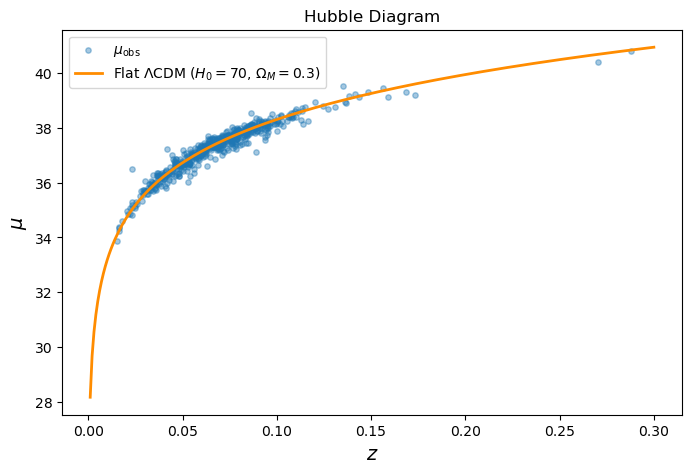

In [9]:

scriptM_fit = result.x
print(f"Fitted script-M: {scriptM_fit:.3f}")

#Redefine our distance modulus with the fitted script-M:
df["mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - scriptM_fit

mu_th = cosmo.distmod(z_grid).value

# Everything else stays the same:
plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_th, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram")
plt.legend()
plt.show()

# Now lets try to see What Accounting for the Error Looks like in the Simple Case of Just adding a constant scatter #

This suggests the following for us. There's some intrinsic scatter in the system that we need to account for 
when it comes to weighing the uncertainty of our sample. 

chi2/dof = 8.06

$\chi^2 = \sum_i \frac{(\Delta\mu_i)^2}{\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2}$

And in fact we can actually kind of guess what that value is by playing around with that intrinsic value. 

You can see in the below code that we imporve the following metric by using the intrinsic scatter value used by Ginolin et al. 

χ²/dof = 366 / (200 − 1) = 1.84. Better than 8.07 without σ_int, but still above 1. That means σ_int = 0.15 isn't quite enough — your data has more intrinsic scatter than that. And will necessitate fitting for the scatter as well.

Ultimately we would have to fit for this intrinsic value in order to get the best offset possible. Now although the following chi squared equation
is the correct one to use:

$\chi^2(\mathscr{M},\sigma_{\mathrm{int}}) = \sum_i \frac{\left(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i} - \mathscr{M}\right)^2}{\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2}$

we end up posing a tough situation for our minnimizing function. Primarily now we have to minimize for $\mathscr{M}$ and for $\sigma_{\mathrm{int}}^2$. This requires using a different
function instead of `minimize_scalar` we will need to use `minimize`. That is not a big deal. However, we are now minimizing across two parameters, also not a big deal. The funciton can handle that 
with absolutely no problem. 

But the parameter $\sigma_{\mathrm{int}}$ is in the denominator. And thus the computer, with
its computer brain will just crash by setting $\sigma_{\mathrm{int}}$ to infinity. 




In [10]:

# Create a new data frame where we only keep SNe with z < 0.06 to construct a volume-limited sample. 
# Note this is done to our data and our sample. We are not using the Ginolin data but rather following in their
# footsteps. 


df_vlim = df[df["ZTF_redshift"] < 0.06].copy()

print(f"Volume-limited sample has: {len(df_vlim)} SNe (z < 0.06)")

# Need to put .value here or it will throw an error. 
mu_th_vlim = cosmo.distmod(df_vlim["ZTF_redshift"]).value

# Construct the chi2 function to minimize. 

sigma_int = 0.15  # fixed, not fitted

def chi2(script_M):
    mu_obs = -2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - script_M
    residuals = mu_obs - mu_th_vlim
    sigma_total = np.sqrt(df_vlim["sigma_mu"]**2 + sigma_int**2)
    return np.sum(residuals**2 / sigma_total**2)

# Note minimize_scalare takes whatever function I give it and
# minimizes it over that function's single input argument. 
result = minimize_scalar(chi2)
print("\n")
print(result)

Volume-limited sample has: 200 SNe (z < 0.06)


 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 366.31184687475906
       x: -29.753223817247413
     nit: 4
    nfev: 9


# Negative Log-Likelihood Minimization (Volume-Limited Sample - Always Remember to Volume Limit)

Since $\sigma_{\mathrm{int}}$ is a free parameter, we minimize the
negative log-likelihood instead of plain $\chi^2$:

$$-2\ln\mathcal{L} = \sum_i \left[\frac{\Delta\mu_i^2}{\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2} + \ln\left(\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2\right)\right]$$

Please see appendix 

In [11]:
def neg_loglike_vlim(params):
    script_M, sigma_int = params
    mu_obs = -2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - script_M
    sigma_total = np.sqrt(df_vlim["sigma_mu"]**2 + sigma_int**2)
    residuals = mu_obs - mu_th_vlim
    return np.sum(residuals**2 / sigma_total**2) + np.sum(2 * np.log(sigma_total))

result_vlim = minimize(neg_loglike_vlim, [19.5, 0.12], method="Nelder-Mead")
scriptM_vlim, sigma_int_vlim = result_vlim.x
print(result_vlim)

print(f"script-M  = {scriptM_vlim:.4f}")
print(f"sigma_int = {sigma_int_vlim:.4f} mag")

df_vlim["residual"] = (-2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - scriptM_vlim) - mu_th_vlim
df_vlim["sigma_total"] = np.sqrt(df_vlim["sigma_mu"]**2 + sigma_int_vlim**2)

chi2 = np.sum(df_vlim["residual"]**2 / df_vlim["sigma_total"]**2)
print(f"chi2/dof = {chi2 / (len(df_vlim) - 2):.2f}")

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -381.3926680606253
             x: [-2.975e+01  2.140e-01]
           nit: 59
          nfev: 111
 final_simplex: (array([[-2.975e+01,  2.140e-01],
                       [-2.975e+01,  2.140e-01],
                       [-2.975e+01,  2.139e-01]]), array([-3.814e+02, -3.814e+02, -3.814e+02]))
script-M  = -29.7519
sigma_int = 0.2140 mag
chi2/dof = 1.05


# Apppendix - Where does $\mathscr{M}$ come from? # 
#

Where does script_M come from. 

### The theory side

Cosmology predicts how far away something is based on its redshift.
The theoretical distance modulus is:

$\mu_{\mathrm{th}}(z) = 5\log_{10}\left(\frac{d_L(z)}{1\;\mathrm{Mpc}}\right) + 25$

where $d_L(z)$ is the luminosity distance. Here's the key:
$d_L$ depends on $H_0$ because:

$d_L(z) = \frac{c(1+z)}{H_0} \int_0^z \frac{dz'}{\sqrt{\Omega_M(1+z')^3 + \Omega_\Lambda}}$

See that $1/H_0$ out front? That means $\mu_{\mathrm{th}}$ contains a
term $-5\log_{10}(H_0) + \mathrm{const}$.

### The observation side

The Tripp equation gives:

$\mu_{\mathrm{obs}} = -2.5\log_{10}(x_0) + \alpha x_1 - \beta c - M_B$

This contains $M_B$ (the absolute magnitude of a "standard" SN Ia).

### The residual

When you compute the Hubble residual:

$\Delta\mu = \mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$

The $M_B$ from the observation side and the $H_0$ from the theory side
combine into a single constant offset. No matter how hard you try, you
cannot separate them — changing $M_B$ by some amount has the exact
same effect as changing $H_0$ by some corresponding amount. This is
the **degeneracy**.

### The solution: script-M

Instead of pretending we know $M_B$ and $H_0$ separately, we define:

$\mathscr{M} = M_B - 5\log_{10}\left(\frac{c/H_0}{1\;\mathrm{Mpc}}\right) + 25$

This is one number that captures both. We don't know what $M_B$ is.
We don't know what $H_0$ is. But we can find the combination that
makes our observed data match the theoretical curve. That's all we need.

# Appendix: Chi-Squared Minimization


The textbook chi-squared statistic is designed for binned count data,
where the expected count serves as the variance estimate:

$\chi^2 = \sum_i \frac{(\mathrm{observed}_i - \mathrm{expected}_i)^2}{\mathrm{expected}_i}$

This form assumes Poisson-distributed counts, where the variance
equals the mean. It is commonly used for goodness-of-fit tests on
histograms and contingency tables
(see https://en.wikipedia.org/wiki/Minimum_chi-square_estimation)).

In our analysis, each data point is a continuous measurement
(distance modulus $\mu_{\mathrm{obs}}$) with its own individually
propagated uncertainty $\sigma_{\mu,i}$ from the SALT2 light-curve
covariance matrix. The appropriate form is:

$\chi^2 = \sum_i \frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{\sigma_{\mu,i}^2}$

The denominator is the variance of each measurement, not the
expected value. This allows well-measured SNe (small $\sigma_\mu$)
to anchor the fit while noisy measurements are downweighted.

The reduced chi-squared normalizes by the degrees of freedom
$\nu = n - m$, where $n$ is the number of data points and $m$
is the number of fitted parameters
(see https://en.wikipedia.org/wiki/Reduced_chi-squared_statistic):

$\chi^2_\nu = \frac{\chi^2}{\nu}$

- $\chi^2_\nu \approx 1$: model adequately describes the data
- $\chi^2_\nu \gg 1$: model is missing error or its a wrong model (e.g., intrinsic scatter) see: https://www.nevis.columbia.edu/~seligman/root-class/html/appendix/statistics/ChiSquaredDOF.html
- $\chi^2_\nu \ll 1$: uncertainties are overestimated







# Appendix - Derivation: From Gaussian Probability to Log-Likelihood to Chi-Squared
# Appendix - Explanation: Why we need the log likelyhood to begin with

## Step 1: One data point

You measure one SN Ia. You get $\mu_{\mathrm{obs}}$. Theory
predicts $\mu_{\mathrm{th}}$. Your measurement has uncertainty
$\sigma$. If the errors are Gaussian, the probability of
getting your observed value is:

$$P(\mu_{\mathrm{obs}} | \mu_{\mathrm{th}}, \sigma) = \frac{1}{\sqrt{2\pi}\,\sigma} \exp\left(-\frac{(\mu_{\mathrm{obs}} - \mu_{\mathrm{th}})^2}{2\sigma^2}\right)$$

This is just the Gaussian bell curve. The peak is at
$\mu_{\mathrm{th}}$ and the width is $\sigma$.

## Step 2: Many data points

You have $N$ independent SNe. The probability of observing
ALL of them is the product of individual probabilities:

$$\mathcal{L} = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi}\,\sigma_i} \exp\left(-\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{2\sigma_i^2}\right)$$

This product is the **likelihood**. Bigger $\mathcal{L}$ = data
is more consistent with the model.

## Step 3: Take the log

Products of tiny numbers cause numerical underflow. Taking
the log turns products into sums:

$$\ln\mathcal{L} = \sum_i \left[-\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{2\sigma_i^2} - \ln(\sigma_i) - \frac{1}{2}\ln(2\pi)\right]$$

We want to **maximize** this. Equivalently, **minimize** the
negative. Multiply by $-2$ (convention to get nice numbers):

$$-2\ln\mathcal{L} = \sum_i \left[\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{\sigma_i^2} + 2\ln(\sigma_i)\right] + N\ln(2\pi)$$

The $N\ln(2\pi)$ term doesn't depend on any parameters, so
we drop it:

$$-2\ln\mathcal{L} = \sum_i \left[\frac{\Delta\mu_i^2}{\sigma_i^2} + 2\ln(\sigma_i)\right]$$

**This is the formula we use.** It came from nothing more than
"errors are Gaussian" and "data points are independent."

## Step 4: Where does chi-squared come from?

Look at what we just derived:

$$-2\ln\mathcal{L} = \underbrace{\sum_i \frac{\Delta\mu_i^2}{\sigma_i^2}}_{\chi^2} + \underbrace{\sum_i 2\ln(\sigma_i)}_{\text{log term}}$$

Now ask: **what if $\sigma_i$ is fixed** (doesn't depend on
the parameters you're fitting)?

Then $\sum 2\ln(\sigma_i)$ is a constant. Adding or subtracting
a constant doesn't change where the minimum is. So you can
drop it:

$$-2\ln\mathcal{L} = \chi^2 + \mathrm{const}$$

Minimizing the log-likelihood IS minimizing chi-squared.
**Chi-squared is a special case of the log-likelihood when
the uncertainties are fixed.**

## Step 5: When chi-squared breaks

In our problem, $\sigma_{\mathrm{total},i} = \sqrt{\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2}$, and $\sigma_{\mathrm{int}}$ is a free parameter. Now $\sigma_i$ changes during the fit, so the log term is no longer constant. You cannot drop it.

If you try to minimize just $\chi^2$:

$$\chi^2 = \sum_i \frac{\Delta\mu_i^2}{\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2}$$

Increasing $\sigma_{\mathrm{int}}$ always makes the denominator
bigger, always makes $\chi^2$ smaller. No minimum exists in the
$\sigma_{\mathrm{int}}$ direction. The optimizer sends
$\sigma_{\mathrm{int}} \to \infty$ and reports $\chi^2 = 0$.

The log term fixes this:

$$-2\ln\mathcal{L} = \sum_i \frac{\Delta\mu_i^2}{\sigma_i^2} + \sum_i 2\ln(\sigma_i)$$

- Increasing $\sigma_{\mathrm{int}}$ shrinks the first sum (good)
- Increasing $\sigma_{\mathrm{int}}$ grows the second sum (bad)
- The optimizer finds the balance → that's the fitted $\sigma_{\mathrm{int}}$